In [1]:
import glob
from scalesurfer import fetch_all_models, ScaleSurfer

## Inference Example

This notebook runs ScaleSurfer inference on a subset of ADNI images.

- dtype: For non-NIVIDA hardware, use: `volume_dtype="float32"`.
- async: async writing keep the GPU using busy, writing the results to disk on a background thread to not block that next batch from the GPU.


In [2]:
# Download models from huggingface
fetch_all_models(fs_versions=7)

{'volume-v7': PosixPath('/home/rph/.cache/huggingface/hub/models--rphammonds--scalesurfer-v7/snapshots/c9f7e092567fba60363a6d188ff4e9daec148f94/transunet3d.safetensors'),
 'stats-v7': PosixPath('/home/rph/.cache/huggingface/hub/models--rphammonds--scalesurfer-stats-v7/snapshots/b2436ae07cba5e532a44ac52d13dc393f9aab26b/stats_model.safetensors')}

In [3]:
# Anatomical images
anat_files = glob.glob("/home/rph/scalesurfer/data/adni_bids/**/*_T1w.nii.gz", recursive=True)
anat_files.sort()
anat_files = anat_files[:96]
subjects = [i.split("/")[6] for i in anat_files]

# Required input data arguments
print(subjects[:2])
print(anat_files[:2])
output_dir = "/home/rph/scalesurfer/scalesurfer_subjects"

['sub-002S0559', 'sub-002S0619']
['/home/rph/scalesurfer/data/adni_bids/sub-002S0559/ses-20060627/anat/sub-002S0559_ses-20060627_T1w.nii.gz', '/home/rph/scalesurfer/data/adni_bids/sub-002S0619/ses-20060601/anat/sub-002S0619_ses-20060601_T1w.nii.gz']


In [4]:
surfer = ScaleSurfer(
    anat_files=anat_files,
    subjects=subjects,
    subject_dir=output_dir,
    fs_version=7,
    volume_dtype="bfloat16",
    overwrite=True,
    n_jobs_cpu=-1,
    progress=True,
    verbose=True,
    async_writes=True,
    writer_backend="thread",
    writer_workers=8,
    writer_queue_size=64,
    inference_num_workers=2,
    prefetch_factor=2,
)

In [5]:
# Conform images to 256^3
surfer.prepare_images()

Conforming images:   0%|          | 0/96 [00:00<?, ?it/s]

[scalesurfer] prepare_images: 29.9s total, 3.21 img/s (0.3s/img) for 96 subject(s)


In [6]:
# Predict aparc+aseg
surfer.predict_volumes(
    batch_size=3,
    write=True,
)

[scalesurfer] predict_volumes: async volume writes enabled backend=thread workers=8 queue_size=64


Predicting volumes:   0%|          | 0/32 [00:00<?, ?it/s]

[scalesurfer] predict_volumes: 20.7s total, 4.64 img/s (0.2s/img) for 96 subject(s)


In [7]:
# Predict FreeSurfer stats: cortical thickness, etc
df_stats = surfer.predict_stats(
    batch_size=6,
    return_format="wide",
    write=True,
)

Predicting stats:   0%|          | 0/16 [00:00<?, ?it/s]

[scalesurfer] predict_stats: async stats writes enabled backend=thread workers=8 queue_size=64
[scalesurfer] predict_stats: 37.4s total, 2.56 img/s (0.4s/img) for 96 subject(s)


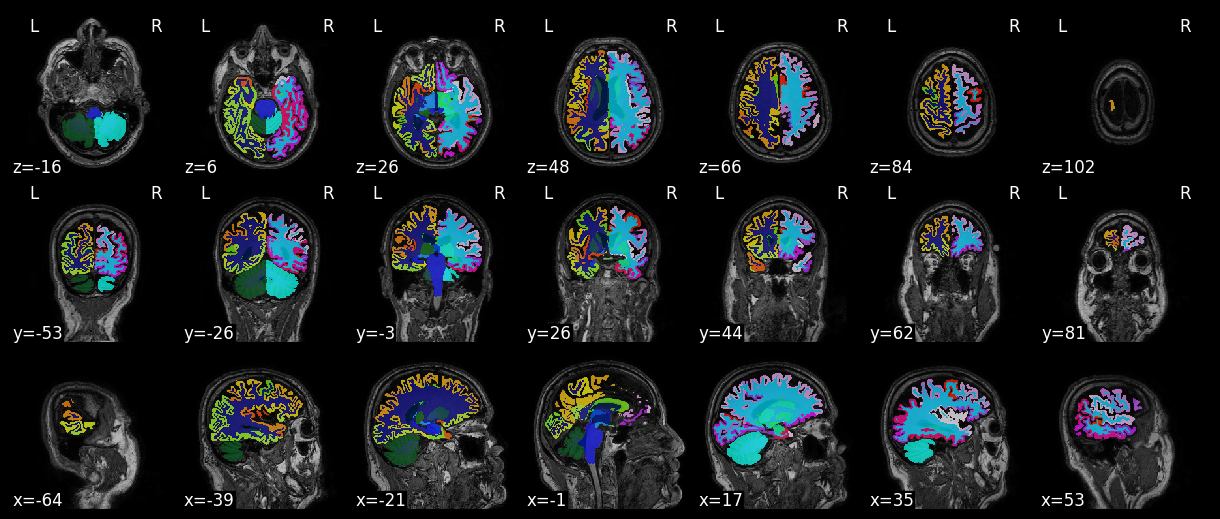

In [8]:
# View aparc+aseg prediction result
surfer.plot_volume(subjects[0])

In [9]:
# Dataframe of FreeSurfer like stats
df_stats

feature,subject,aseg__3rd-Ventricle__Volume_mm3,aseg__4th-Ventricle__Volume_mm3,aseg__5th-Ventricle__Volume_mm3,aseg__Brain-Stem__Volume_mm3,aseg__CC_Anterior__Volume_mm3,aseg__CC_Central__Volume_mm3,aseg__CC_Mid_Anterior__Volume_mm3,aseg__CC_Mid_Posterior__Volume_mm3,aseg__CC_Posterior__Volume_mm3,...,wmparc__wm-rh-precentral__Volume_mm3,wmparc__wm-rh-precuneus__Volume_mm3,wmparc__wm-rh-rostralanteriorcingulate__Volume_mm3,wmparc__wm-rh-rostralmiddlefrontal__Volume_mm3,wmparc__wm-rh-superiorfrontal__Volume_mm3,wmparc__wm-rh-superiorparietal__Volume_mm3,wmparc__wm-rh-superiortemporal__Volume_mm3,wmparc__wm-rh-supramarginal__Volume_mm3,wmparc__wm-rh-temporalpole__Volume_mm3,wmparc__wm-rh-transversetemporal__Volume_mm3
0,sub-002S0559,1446.713379,2563.412109,0.054574,22821.765625,1058.454834,505.389893,493.527588,592.742859,1075.926880,...,13649.601562,9027.307617,2032.286865,13174.700195,17455.322266,11682.606445,7546.644531,9427.427734,839.744812,590.337646
1,sub-002S0619,1872.491211,2882.180176,-0.036191,21205.603516,1101.450562,271.234100,304.325745,536.987244,1105.151367,...,15059.994141,10204.312500,2105.161377,15048.443359,19040.865234,13973.328125,8002.120117,10281.874023,886.065430,619.128357
2,sub-002S0685,1379.833252,2260.146973,0.013437,18818.421875,901.302246,368.362732,386.779846,489.101624,954.223267,...,13172.117188,8814.043945,1795.157715,12710.518555,16332.553711,11769.376953,6526.200195,7988.608398,745.927917,558.129272
3,sub-002S0816,1300.861816,2287.464111,0.063607,21209.628906,1021.811890,524.353821,504.790253,586.996216,1055.287964,...,12821.551758,8488.712891,1885.042236,12394.514648,16365.396484,10958.062500,6934.215820,8779.779297,806.841125,571.382141
4,sub-002S0938,1123.701538,1840.165039,0.011636,17110.667969,783.871155,418.934265,419.198425,455.453094,851.413330,...,12286.549805,8204.443359,1665.085815,11612.556641,14987.150391,10896.578125,5989.601074,7266.108887,677.254333,544.308228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,sub-005S6084,1874.005371,3000.005859,0.038946,21249.921875,1168.504272,284.886505,328.189423,562.980896,1138.373535,...,14222.542969,9147.656250,2015.882446,13750.452148,17649.255859,12687.201172,7501.588379,9849.718750,828.179504,575.519653
92,sub-006S0484,1215.185303,2159.055420,-0.009300,22604.125000,982.643311,590.739136,577.554565,604.655945,1069.417236,...,15829.340820,10784.795898,2173.769287,15874.402344,20583.214844,14027.235352,8308.829102,10115.485352,856.568359,680.447510
93,sub-006S0547,1407.287842,2239.340820,-0.018597,19017.330078,898.743042,383.834564,382.110474,499.672394,958.169983,...,13258.819336,8856.406250,1817.108398,13247.571289,16810.882812,12193.372070,6838.279297,8660.164062,770.386108,611.731995
94,sub-006S0653,1385.750732,2195.877441,0.023533,17711.101562,864.891235,316.918396,343.927734,472.077209,917.135742,...,12177.775391,7852.719238,1620.238647,11284.533203,14614.093750,10822.933594,5936.708496,7374.541016,679.362976,530.143616
